<p align="center">
  <img src="./yibo-quant.jpg" alt="课程封面" width="1300"/>
</p>


# 《和Yibo零基础学习量化金融》
## 从Python到AI量化交易实战 第一期
### 第一章：什么是量化金融？

---

## 本章你将学会

- ✅ 量化金融是什么（用人话，不堆术语）
- ✅ 量化在做什么：**假设 → 数据 → 验证 → 规则**
- ✅ 为什么 **Python** 适合零基础入门
- ✅ **第一次用代码下载真实股票数据**（本章爽点 🎉）

**当前等级**  
🎮 **Lv.1 量化探索者**

**本章难度**  
⭐☆☆☆☆

**预计学习时间**  
45～60 分钟

**前置知识**

- 无需金融背景、无需高等数学
- 会基本 Python / 能运行 Jupyter 更佳（不会也可边学边跑）

---

> 我是 **Yibo**。在学习 AI、数据科学和量化金融的路上，我发现很多教程要么太学术，要么太碎片化——所以决定从零整理这份笔记，**和你一起**把量化从「高深学科」变成「能动手的世界」。


### 1.1 什么是量化金融？

<center>
<img src="./Simons1st.jpg" width="400" style="display:inline-block; margin-right:10px;">
</center>
现代意义上的量化金融通常是指运用包括数学、统计学、计算机科学和金融理论在内的多学科知识和方法,通过建立数学模型和算法对大量历史和实时数据的分析和挖掘来进行金融分析、定价、交易和风险管理的一门具有明显跨学科性质的学科领域。量化金融的核心目标是用数据驱动的方式寻找市场中的规律和模式,优化投资决策,提高收益或降低风险。从实践上来看,量化金融既是一门科学,又是一门艺术,即同时具有科学性和艺术性。量化金融是一门科学,这是因为这门学问以数据为基础、以模型为依托、以算法为工具,通过实施各种量化策略进行金融分析和交易,因此,量化金融具有实证性、可复制性以及自我修正性。这些都是科学的基本特征。同时,量化交易还是一门用算法和模型来赚钱的艺术。艺术是达到某种预期效果的具有创造力和想象力的有效方法或者“诀窍”。投资者在量化金融实践中,既要运用相关知识和方法,又要发挥其创造性,谋划出一种有用的方法来实现高收益或者低风险的目标。总之,量化金融是科学与艺术的结合,它既有严谨的数学模型和统计分析,又有灵活的策略调整和心态把握。
<center>
<img src="./Simons2nd.jpg" width="800" height="400" style="display:inline-block;">
</center>
大数据、人工智能、机器学习、大语言模型、量子计算等技术的迅速发展为量化金融带来了新的机遇,提供了新的发展空间。这些技术可以处理和分析海量、多模态市场数据,挖掘出这些数据背后错综复杂的模式、趋势与规律,可以有效提升投资者对市场的认知以及市场洞察力,便于投资者开发更先进的量化交易策略。但是,对于量化金融也需要辩证来看待。“成也萧何,败也萧何。”比如詹姆斯·西蒙斯的大奖章基金(Medallion),利用量化交易实现了高额的年回报率,被誉为是最成功的对冲基金。但是,2013年8月16日某证券的乌龙事件,震惊中国股市,令该证券命悬一线,也是源于量化交易。随着AI等技术在量化金融领域中的应用,量化交易已逐渐改变了金融市场的游戏规则。过去,个人炒股靠的是经验和判断,现在,买卖股票靠的更多的是程序和算法。毫无疑问,随着AI等技术的加入和深度应用,金融市场会变得更加复杂。此外,AI还具备自我学习与优化能力,能自动持续微调和优化量化交易策略参数,进而推动量化交易策略的自我更新、迭代与进化,从而让量化交易策略更契合市场动态和价格走势,这可以显著提升金融交易的成功概率与收益水平。在这样的时代,对于普通投资者和广大股民而言,最大的挑战或许不是怎么选股,而是如何在机器和算法的时代里找到自己的生存之道。

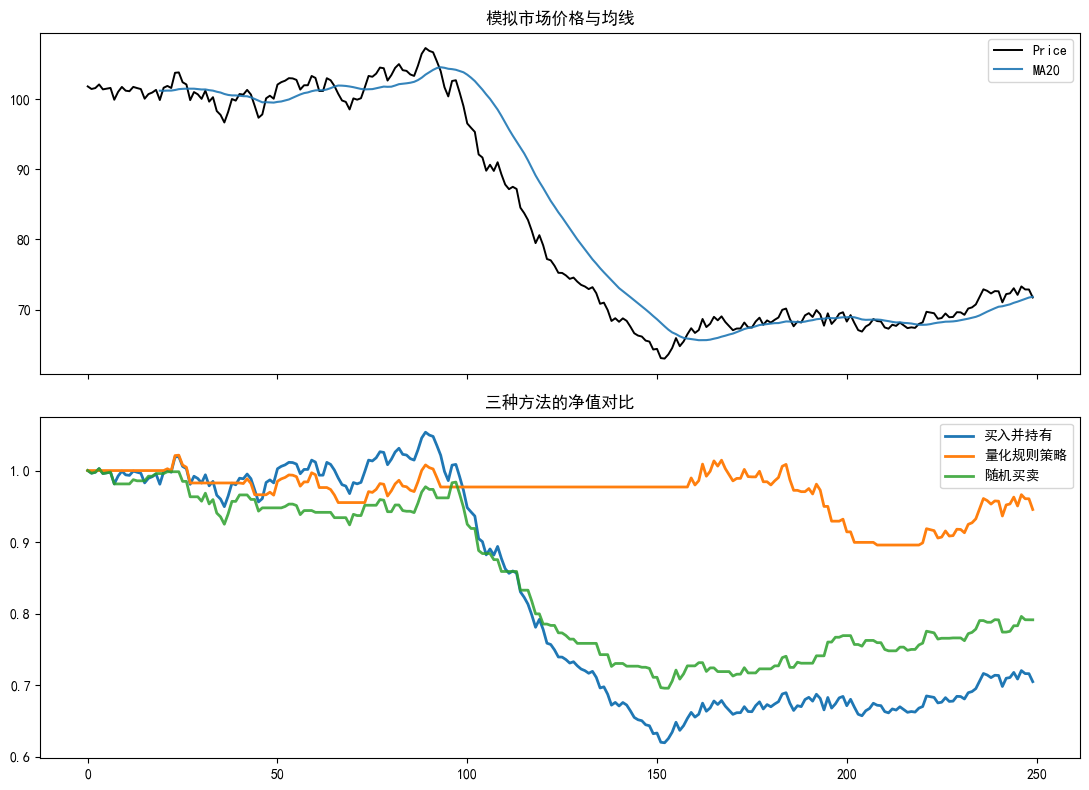

In [1]:
# ========== 导入本实验需要的库 ==========
import numpy as np              # 做数值计算（随机数、累乘价格等）
import pandas as pd             # 处理表格数据（像 Excel 一张表）
import matplotlib.pyplot as plt   # 画折线图、对比图
import platform

# ========== 让图表能正确显示中文 ==========
# plt.rcParams['font.sans-serif'] = ['SimHei']   # 指定中文字体（Windows 常用黑体）
# 自动适配不同系统的中文字体
sys_type = platform.system()
if sys_type == "Windows":
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
elif sys_type == "Darwin":  # macOS
    plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Arial Unicode MS"]
else:  # Linux
    plt.rcParams["font.sans-serif"] = ["WenQuanYi Zen Hei", "Noto Sans CJK SC"]

plt.rcParams['axes.unicode_minus'] = False    # 让坐标轴上的负号正常显示
np.random.seed(7)                             # 固定随机种子：每次运行随机数相同，方便对照

# ========== 第1步：模拟三段行情（涨→跌→恢复）==========
n1, n2, n3 = 90, 40, 120                      # 三个阶段分别有多少个交易日
ret = np.r_[                                    # 把三段「日收益率」拼成一条长数组
    np.random.normal(0.0010, 0.010, n1),        # 阶段1：平均每天略涨，波动较小
    np.random.normal(-0.012, 0.015, n2),       # 阶段2：平均每天偏跌，波动更大
    np.random.normal(0.0012, 0.012, n3)        # 阶段3：震荡恢复
]                                              # 数组拼接结束
price = 100 * np.cumprod(1 + ret)              # 起点100元，每天按 (1+收益率) 连乘得到价格

# ========== 第2步：做成 DataFrame，并算每日涨跌比例 ==========
df = pd.DataFrame({"close": price})            # 把价格放进表格，列名叫 close
df["ret"] = df["close"].pct_change().fillna(0) # pct_change = 日收益率；第一天填 0

# ========== 第3步：量化规则——收盘价在20日均线上方就持有 ==========
df["ma20"] = df["close"].rolling(20).mean()    # rolling(20).mean() = 20日移动平均线
df["signal_quant"] = (df["close"] > df["ma20"]).astype(int)  # 高于均线记1，否则记0

# ========== 第4步：随机买卖策略（对照组，乱买乱卖）==========
rng = np.random.default_rng(7)                 # 随机数生成器（种子7）
df["signal_random"] = rng.integers(0, 2, size=len(df))  # 每天随机 0 或 1

# ========== 第5步：算各策略的日收益（信号用昨天的，避免偷看未来）==========
df["ret_quant"] = df["signal_quant"].shift(1).fillna(0) * df["ret"]    # 量化策略收益
df["ret_random"] = df["signal_random"].shift(1).fillna(0) * df["ret"]  # 随机策略收益
df["ret_buyhold"] = df["ret"]                                          # 买入并持有：天天在场

# ========== 第6步：把日收益连乘成「净值曲线」（起点相当于1块钱）==========
for col in ["ret_quant", "ret_random", "ret_buyhold"]:   # 遍历三种收益列
    df[f"nav_{col}"] = (1 + df[col]).cumprod()         # (1+r) 连乘 = 累计净值

# ========== 第7步：画图——上图价格+均线，下图三种净值 ==========
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)  # 2行1列子图，共用横轴

axes[0].plot(df["close"], label="Price", color="black", linewidth=1.4)  # 模拟收盘价
axes[0].plot(df["ma20"], label="MA20", color="tab:blue", alpha=0.9)     # 20日均线
axes[0].set_title("模拟市场价格与均线")                                  # 子图标题
axes[0].legend()                                                        # 显示图例

axes[1].plot(df["nav_ret_buyhold"], label="买入并持有", linewidth=2)       # 买入持有净值
axes[1].plot(df["nav_ret_quant"], label="量化规则策略", linewidth=2)     # 规则策略净值
axes[1].plot(df["nav_ret_random"], label="随机买卖", linewidth=2, alpha=0.85)  # 随机策略
axes[1].set_title("三种方法的净值对比")                  # 下图标题
axes[1].legend()                                    # 显示下图图例

plt.tight_layout()   # 自动调整子图间距，避免标签被裁切
plt.show()           # 在 Notebook 里显示图片


>## ***量化不是“猜明天涨跌”，而是“把交易想法写成规则，然后批量验证”。***

### 1.2 为什么越来越多人做量化？

随着生成式AI技术飞速迭代，DeepSeek、ChatGPT等主流大模型凭借顶尖的语义理解、逻辑推演与多模态处理能力，在金融赛道快速落地出圈。其中，量化投资、风险管理两大核心领域受益最为显著，展现出极强的技术赋能价值与广阔的落地前景。如今，生成式AI的应用场景持续拓宽、使用成本不断降低，全行业智能化转型已然成为不可逆趋势，一场颠覆性的生产力革命正在席卷各行各业。而高度依赖数据运算、逻辑分析与策略迭代的量化金融，也迎来了前所未有的变革机遇。为帮助零基础学习者快速建立直观认知，本文将通俗拆解DeepSeek在量化金融领域的核心落地场景，带大家看懂AI赋能量化投资的核心逻辑与实用价值。

在量化金融实操中，DeepSeek、ChatGPT能够为普通投资者、量化入门学习者提供高效的数据分析能力与科学决策支撑，彻底打破了传统量化的专业壁垒。市场趋势预测是量化投资的入门核心，借助AI大模型，我们可以快速拆解股票、汇率、大宗商品等各类金融品类的历史行情数据，快速搭建轻量化分析逻辑，一键生成短期走势研判报告，无需复杂的建模编程。

整套操作零门槛、极易上手，零基础也能轻松复刻。我们只需向大模型输入精准提示词：基于过去5年上证指数数据，预测未来3个月上证指数走势及关键影响因素。DeepSeek将自动复盘五年历史行情规律，从乐观、中性、悲观三种市场维度，精准测算未来3个月指数波动区间，深度拆解行情涨跌的核心影响因子，同步配套行业配置思路与风险预警提示，输出一套完整、可落地的标准化分析结论。虽然AI生成的分析逻辑偏向轻量化，精度不及机构高阶量化模型，但对于新手搭建市场分析思维、快速研判行情趋势，具备极高的学习参考价值。

除了专业的市场趋势分析，DeepSeek、ChatGPT还能化身大众专属的免费智能理财顾问，精准解决普通人家庭资产配置、个人投资规划的核心痛点。科学分配闲置资金、搭建多元化投资组合，是每个人必备的理财能力。但绝大多数普通投资者缺乏专业金融知识，普遍存在资金分配混乱、投资方向模糊、不懂风险把控等问题，而AI的出现完美解决了这一困境。

大家可以结合自身真实收入情况、闲置资金规模、风险承受能力精准提问，例如核心提示词：我是工薪族，年收入30万元，现有闲置资金100万元，无专业投资经验，请提供适配的投资理财配置方案。AI会先梳理个人投资的前置准备要点，再结合普通投资者的稳健需求，将闲置资产科学划分为稳健基石、权益增长、灵活补充三大板块，明确各类资产的最优配置比例。同时配套详细实操步骤、投资避坑要点、标准化示范投资组合。输入的个人信息越详实、需求越精准，AI输出的理财方案适配性、专业性就越强，整体输出效果堪比金融机构初级从业者的专业方案，大幅降低普通人的理财入门门槛。

需要重点明确的是，***现阶段生成式AI始终是辅助学习、辅助分析的工具，绝对不能直接作为投资决策的唯一依据，切忌盲目依赖、跟风操作。***

以上只是DeepSeek在量化金融领域的基础应用场景，其落地价值与实用场景远不止于此。依托生成式AI核心优势——智能逻辑推理、多维度内容生成、创造性思维输出，大模型可以覆盖量化学习、实操、复盘的全流程场景。无论是数据清洗分析、量化策略搭建、历史回测复盘，还是行情深度解读、投资风险拆解，都能借助AI快速梳理思路、解答疑难问题。其输出内容既具备严谨的金融专业逻辑，又能提供创新的分析视角，帮助零基础学习者打破固有思维局限，快速入门量化领域。

这里必须重点强调：量化金融早已不是机构专属，普通人零基础入局的黄金时代，已经正式到来！

以往大家普遍认为，量化投资是资深从业者、专业机构的专属领域，门槛极高、普通人难以触碰。但如今，三大核心条件彻底打破了传统壁垒，让量化学习变得简单有趣、人人可学，极大激发新手的实操热情与学习动力。
- 第一，AI技术全面普及。各类大模型工具轻量化、易获取、低成本，无需深厚的算法、金融功底，普通人靠精准提示词，就能完成专业的量化分析、策略构思与行情研判，彻底告别复杂建模门槛。
- 第二，金融数据获取极度便捷。当下各类合规、公开的股票、指数、大宗商品等市场行情数据全面开源，无需专属机构数据源，普通人随手即可获取完整的量化分析素材，满足全部入门实操需求。
- 第三，Python量化生态高度成熟。经过多年迭代，Python已形成完善的量化开源工具库，数据处理、可视化绘图、策略回测、风险分析等各类工具齐全、适配性极强。搭配AI辅助，零基础学习者可以跳过枯燥的基础摸索，快速完成完整的量化实操流程。
  
AI赋能、数据开源、生态成熟，三大优势相辅相成，彻底改写了量化金融的入门规则，让普通人也能零成本、低门槛踏入量化领域，亲手做属于自己的量化分析与投资策略。
当然，我们始终要秉持辩证理性的使用思维。金融市场充满随机性与不确定性，AI分析存在天然的滞后性与局限性，输出内容并非绝对准确。大家可以将AI内容作为学习参考、思路启发、分析依据，但必须结合自身认知、市场实时动态综合判断，不盲目依赖、不跟风盲从。这才是零基础学习者利用AI赋能量化学习、辅助投资的正确打开方式。

>### ***投资有风险，入市需谨慎***

### 1.3 量化金融到底在做什么？

很多零基础同学最开始都会有一个误区：量化金融是不是“预测股市涨跌”的神奇技术？

答案非常直白：**量化不做预言，量化只做一件事——寻找市场规律、验证规律、利用规律。**

我们用一个所有人都能看懂的真实场景，带你第一次真正理解量化思维。

**生活化案例：**

如果一只股票，已经连续上涨 5 天。

凭感觉、凭直觉的人会想：
“都涨五天了，第六天应该还会继续涨吧？”
或者：
“涨太多了，第六天肯定要跌、要回调。”

这些都是主观感觉、情绪判断、没有依据。

而量化，完全不凭感觉。

量化会把这个问题，变成一套可以被数据验证的科学流程。这也是量化金融从头到尾在做的全部工作。

量化金融的本质，就是固定的四步闭环：**提出假设 → 量化定义 → 历史验证 → 沉淀规则迭代**

#### 第一步：提出一个可检验的问题（建立假设）
我们不猜涨跌，我们提出一个清晰、可验证的问题：

「股票连续上涨5天之后，第6天上涨的概率会不会更高？」

这就是量化的起点：**所有策略，始于假设，始于问题。**

#### 第二步：把自然语言变成可计算的条件（量化定义）
人脑能看懂“连续涨5天”，但电脑看不懂。

量化的核心工作之一，就是把模糊的感觉，变成精准的代码规则：

“连续上涨5天” → 定义为：**该股票前5个交易日的每日收益率全部大于0**

至此，模糊的经验，变成了机器可以批量识别、批量统计的标准条件。

#### 第三步：用海量历史数据批量验证（回测统计）
接下来我们不主观臆断，直接让数据说话：

遍历市场过去十几年的所有行情，找出所有“连续上涨5天”的样本，统计每一次出现该形态后，第6天上涨、下跌的概率分别是多少。

最后我们得到一个客观结果：
到底是继续涨的概率大，还是回调的概率大。

#### 第四步：沉淀为规则，并持续迭代优化（形成策略）
如果数据证明：该规律具备统计优势、长期有效、风险可控。

我们就可以结合交易成本、波动风险、仓位管理，把它变成一套可落地的量化交易规则。

如果数据证明规律无效，我们就直接舍弃，绝不凭感觉硬做。

---

>## **总结一句话：**
>## ***量化金融不预测未来，它只统计过去、验证规律、寻找概率优势、长期依靠正期望收益赚钱。***
>## 这也是量化交易和普通人炒股最大的区别：***情绪退出市场，数据掌控一切。***

### 1.4 一个最简单的量化流程?

在真正开始写策略之前，我们需要先知道：
**一个完整的量化系统到底是如何运行的？**
虽然真正的量化系统可能非常复杂，但核心流程其实并不难理解。
通常来说，一个最基础的量化流程可以分成下面几个步骤：
<center>
<img src="./quant-diagram.png" width="900" height="300" style="display:inline-block;">
</center>

#### 1️⃣ 获取数据（Data）
量化交易的第一步，永远是：

 **数据**

例如：
- 股票价格
- 成交量
- 财务数据
- 新闻数据

因为量化本质上，就是：

 **“从数据中寻找规律”**

所以：不会获取数据，  就无法开始量化。


#### 2️⃣ 分析数据（Analysis）
拿到数据后，我们会开始观察：

例如：
- 股票是否存在上涨趋势？
- 波动是否很大？
- 是否存在某种规律？
这一阶段，更像：

 **“金融数据分析”**


#### 3️⃣ 设计策略（Strategy）
当我们发现某些规律后，就可以尝试：

 **把规律变成规则**

例如：如果：  
`5日均线 > 20日均线`  
那么：  
买入 这一步，  就是：

 **策略设计**

#### 4️⃣ 回测策略（Backtesting）
但是：
>一个策略看起来有效,不代表真的有效。

所以,我们需要：

 **用历史数据测试它**

例如：
如果这个策略过去5年有效,那么,它未来是否还有可能有效？

这个过程，就叫：

 **回测（Backtesting）**

#### 5️⃣ 模拟交易（Paper Trading）
在真正投入资金之前，很多量化交易者还会：
- 模拟下单
- 模拟交易
- 模拟运行策略

确认系统稳定后,才会进入真实市场。

### 看到这里的小伙伴们
不用担心：  
这一整套流程看起来很多。在接下来的教程里，  我们会：
 **一步一步亲手实现它**

而现在，  
你已经正式进入量化金融世界了。

### 1.5 Python为什么适合量化？

很多人第一次听到“量化金融”时，都会觉得：
>很复杂
>很数学
>很难上手
甚至会以为：**只有金融工程、数学、计算机背景的人才能学习量化。**

但实际上，借助 Python，我们几行代码就能获取真实股票数据并开始分析。

为什么很多量化研究员都使用 Python？原因其实很简单：

>语法简单
>数据分析能力强
>可视化方便
>金融生态成熟

更重要的是：Python 可以完成量化研究的整个流程

#### Python vs 其他编程语言：为什么量化圈选择了Python？

市面上能做数据分析的编程语言不止一种，为什么偏偏是 Python 成了量化领域的"标准语言"？

我们来做一个横向对比：

| 对比维度 | Python | C/C++ | Java | R | MATLAB |
|---------|--------|-------|------|---|--------|
| 学习曲线 | ⭐ 极低，接近自然语言 | 陡峭，需理解指针、内存管理 | 中等，语法冗长 | 中等，偏统计方向 | 低，但场景受限 |
| 运行速度 | 中等（可调用C扩展加速） | 极快 | 快 | 慢 | 中等 |
| 金融库生态 | 极丰富（pandas, numpy, backtrader...） | 几乎没有现成库 | 少量企业级框架 | 统计分析强，交易生态弱 | 金融工具箱收费 |
| 数据处理能力 | 极强（pandas一行搞定） | 需手写大量代码 | 需引入第三方库 | 强，但语法不直观 | 强，但不够灵活 |
| AI/机器学习支持 | 最强（TensorFlow, PyTorch, scikit-learn） | 有，但开发效率低 | 有限 | 有限 | 有工具箱，但社区小 |
| 社区与资源 | 全球最大开发者社区 | 大，但偏底层系统 | 大，偏企业应用 | 小，偏学术统计 | 小，偏高校教学 |
| 授权费用 | 完全免费开源 | 免费 | 免费 | 免费 | **商业授权极贵** |

**结论很明确：**

- **C/C++** 速度最快，但开发效率太低，适合高频交易系统底层开发，不适合策略研究和快速验证
- **R** 统计分析能力强，但交易回测、实盘接口生态薄弱，只适合做学术研究
- **MATLAB** 曾经是金融工程课堂标配，但商业授权费用高昂，且社区生态远不如Python
- **Java** 在大型机构后台系统中常见，但写一个简单的数据分析都需要大量样板代码

**Python 恰好在"易学、生态丰富、AI支持、免费"四个维度同时拿到最优解，这就是它成为量化首选的根本原因。**

#### Python 量化工具链全景：一门语言覆盖整个流程

回顾 1.4 节的量化流程，Python 对每一步都有对应的成熟工具：

```
┌─────────────┐    ┌─────────────┐    ┌─────────────┐    ┌──────────────┐    ┌─────────────┐
│  获取数据    │ →  │  数据处理    │ →  │  分析建模    │ →  │  策略回测     │ →  │  可视化展示  │
│             │    │             │    │             │    │              │    │             │
│  yfinance   │    │  pandas     │    │  numpy      │    │  backtrader  │    │ matplotlib  │
│  akshare    │    │  polars     │    │  scipy      │    │  zipline     │    │ plotly      │
│  tushare    │    │             │    │  statsmodels│    │  vnpy        │    │ seaborn     │
│  ccxt(加密) │    │             │    │  sklearn    │    │              │    │ pyecharts   │
└─────────────┘    └─────────────┘    └─────────────┘    └──────────────┘    └─────────────┘
```
<center>
<img src="./quant-diagram.png" width="500" height="300" style="display:inline-block;">
</center>
**每一个环节，你都不需要从零造轮子，只需要学会调用这些工具。**

我们在后续课程中会逐步学习这些库的核心用法。这里先简单介绍几个最常用的：

| 库名 | 一句话功能 | 量化场景举例 |
|------|----------|------------|
| **pandas** | 表格数据处理的瑞士军刀 | 读取CSV、清洗股票数据、计算移动平均线 |
| **numpy** | 高性能数值计算 | 批量计算收益率、矩阵运算、随机模拟 |
| **matplotlib** | 基础绑图库 | 绘制K线图、收益曲线、分布直方图 |
| **yfinance** | 免费获取Yahoo财经数据 | 一行代码下载任意股票的历史价格 |
| **akshare** | 国内金融数据接口（A股友好） | 获取A股行情、基金净值、宏观经济指标 |
| **backtrader** | 策略回测框架 | 模拟历史交易、评估策略收益与风险 |

#### 感受一下：同一个任务，Python 要写多少代码？

我们用一个真实的量化场景来直观感受 Python 的开发效率：

**任务：计算一组股票收盘价的5日移动平均线**

如果用 **C++** 实现，你大概需要：
```cpp
#include <iostream>
#include <vector>
#include <numeric>

std::vector<double> moving_average(const std::vector<double>& prices, int window) {
    std::vector<double> result;
    for (size_t i = window - 1; i < prices.size(); ++i) {
        double sum = std::accumulate(prices.begin() + i - window + 1, 
                                      prices.begin() + i + 1, 0.0);
        result.push_back(sum / window);
    }
    return result;
}
// 还需要手动读取数据、处理文件格式...大约 50+ 行代码
```

如果用 **Python + pandas** 实现，只需要：
```python
df['MA5'] = df['Close'].rolling(5).mean()
```

**一行代码，完成同样的事情。** 这就是为什么量化研究员用 Python 做策略验证——把时间花在思考策略逻辑上，而不是和底层代码较劲。

#### 动手试一试：3行代码生成随机股价走势

不需要真实数据，我们用 Python 模拟一条"股票价格走势"，直观感受 Python 在量化场景下的表现力：

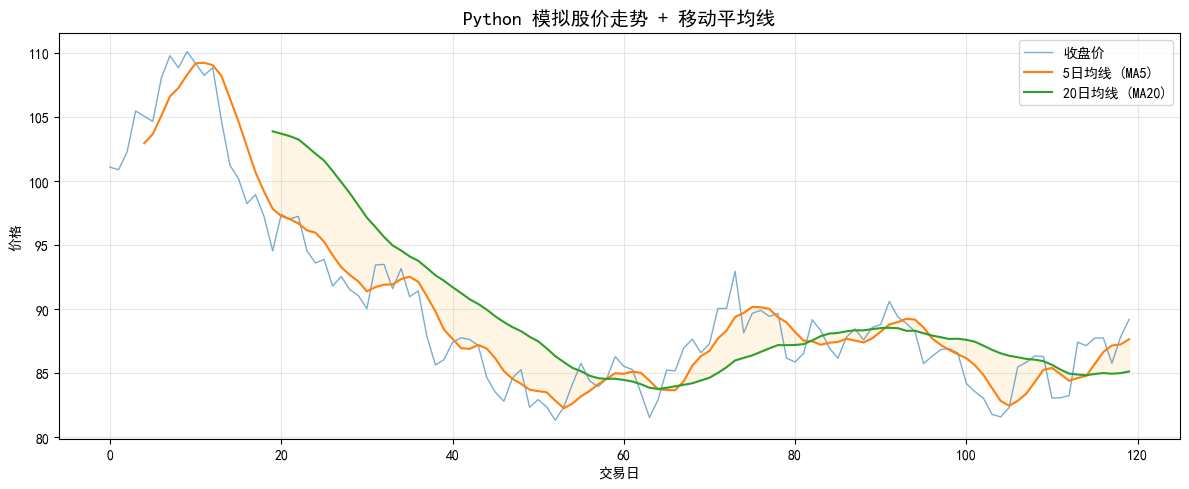

起始价格: ¥101.07
最终价格: ¥89.18
区间收益率: -11.76%
最大回撤价格: ¥81.31
最高价格: ¥110.10


In [2]:
# ========== 导入库 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import pandas as pd                      # 表格数据处理（像 Excel）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']      # 图表中文
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(42)          # 固定随机数，结果可复现
days = 120                  # 一共模拟 120 个交易日
daily_returns = np.random.normal(loc=0.0008, scale=0.02, size=days)  # 每天随机收益率
price = 100 * np.cumprod(1 + daily_returns)     # 从100元出发连乘成价格序列

df = pd.DataFrame({  # 构建表格
    '收盘价': price,                              # 原始模拟收盘价
    '5日均线': pd.Series(price).rolling(5).mean(),   # 最近5天均价
    '20日均线': pd.Series(price).rolling(20).mean()  # 最近20天均价
})  # 执行本行代码

plt.figure(figsize=(12, 5))                     # 创建画布，宽12高5英寸
plt.plot(df['收盘价'], label='收盘价', alpha=0.6, linewidth=1)  # 画折线图
plt.plot(df['5日均线'], label='5日均线 (MA5)', linewidth=1.5)  # 画折线图
plt.plot(df['20日均线'], label='20日均线 (MA20)', linewidth=1.5)  # 画折线图
plt.fill_between(range(days), df['5日均线'], df['20日均线'], alpha=0.1, color='orange')  # 两线之间浅色填充
plt.title('Python 模拟股价走势 + 移动平均线', fontsize=14)  # 设置图标题
plt.xlabel('交易日')                             # 横轴说明
plt.ylabel('价格')  # 设置纵轴标签
plt.legend()                                    # 图例
plt.grid(True, alpha=0.3)                       # 浅色网格，方便读数
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print(f"起始价格: ¥{price[0]:.2f}")              # 第一天价格
print(f"最终价格: ¥{price[-1]:.2f}")              # 最后一天价格
print(f"区间收益率: {(price[-1]/price[0] - 1)*100:.2f}%")  # 整段涨跌幅
print(f"最大回撤价格: ¥{price.min():.2f}")        # 期间最低价
print(f"最高价格: ¥{price.max():.2f}")            # 期间最高价


仅仅 **不到30行代码**，我们就完成了：
- ✅ 生成120天的模拟股价数据
- ✅ 计算 5日 和 20日 移动平均线
- ✅ 绘制带有均线交叉区域的专业图表
- ✅ 输出关键统计指标

如果用 Excel 做同样的事，你需要手动拖拽公式、调整图表格式、反复修改……
如果用 C++ 做，光是绑图部分就需要上百行代码配置图形库。

**Python 让你把精力聚焦在"策略逻辑"而非"技术实现"上——这正是量化研究最需要的。**

#### Python 在量化行业的真实地位

如果你还在犹豫要不要学 Python，以下几个事实可以帮你做出判断：

- **全球顶级对冲基金**（Two Sigma、Citadel、AQR、D.E. Shaw）的研究团队，几乎全部使用 Python 作为主要策略研发语言
- **摩根大通（JPMorgan）** 要求所有资产管理部门的分析师必须学习 Python，并将其列入内部培训核心课程
- **国内头部量化私募**（幻方、明汯、九坤、灵均等）的招聘 JD 中，Python 是出现频率最高的技能要求
- **Jupyter Notebook**（就是你现在正在使用的这个工具）已经成为量化研究员日常工作的标配环境——写代码、看数据、出图表、写报告，全在一个界面完成
- 全球最大的量化社区 **QuantConnect** 和 **Quantopian**（已关闭但影响深远）都以 Python 作为唯一策略编写语言

> **一句话总结：不是 Python 选择了量化，而是量化行业用脚投票选择了 Python。**

### 1.6 第一个量化实验?

### 第一个量化金融概念（理论原点）
<center>
<img src="./Louis Bachelier.jpg" width="900" height="300" style="display:inline-block;">
</center>

**1900年，路易斯·巴舍利耶（Louis Bachelier）提出“股价随机游走与布朗运动”概念，被公认为量化金融的首个核心概念**。他在博士论文《投机理论》中，首次用**概率论与布朗运动**描述股票价格波动，证明短期股价涨跌**随机且不可预测**，奠定了量化金融的理论基石。更早的雏形：1860年代，朱尔斯·雷格纳特（Jules Regnault）通过手工统计巴黎交易所数据，发现**价格波动标准差与时间平方根成正比**，是最早的金融量化统计观察。

这里配套了一个 **布朗运动与随机游走** 的交互动画（数学 + 量化金融双板块），建议在浏览器中打开：

**[打开交互演示](../../assets/interactive/brownian-random-walk.html)**（本地文件，无需联网即可运行）

> 也可参考延伸阅读：[Elysia Tools 版演示](https://elysiatools.com/zh/visualizations/brownian-motion-random-walk)

### 第一个量化金融实验（实战落地）
<center>
<img src="./Edward Thorp.jpg" style="height: 480px; width: auto; object-fit: contain;">
  <img src="./Edward Thorp2.jpg" style="height: 480px; width: auto; object-fit: contain;">

</center>

**1961年，爱德华·索普（Edward Thorp）的“21点算牌实验”，是世界上第一个可复制、可盈利的量化金融实验**。索普（MIT数学家）用**数学建模+概率统计**破解21点规律，提出“高低算牌法”，并结合**凯利公式**管理仓位。同年亲赴拉斯维加斯赌场，用算牌策略实战，**长期稳定盈利**，验证了“数学与概率可击败不确定性游戏”。1967年，索普将这套量化逻辑引入股市，发表《战胜市场》；1969年创立**全球首只量化基金（Convertible Hedge Associates）**，标志量化金融从实验走向规模化应用。


---

### 动手实验：用 Python 亲手验证量化金融的两个理论原点

上面我们了解了两个改变金融历史的核心思想：
- **巴舍利耶**：股价短期波动像布朗运动，本质上是随机游走
- **索普**：即使面对随机性，只要拥有概率优势 + 合理仓位管理，就能长期稳定盈利

接下来，我们用 Python 亲手模拟这两个实验，让抽象理论变成可运行的代码、可观察的图表。

#### 实验一：模拟布朗运动——股价真的是"随机游走"吗？

巴舍利耶在1900年提出：股票价格的短期波动可以用**布朗运动（随机游走）**来描述。

什么是随机游走？想象你站在原点，每一步等概率向左或向右走一步——你的轨迹就是随机游走。股价也类似：每天的涨跌在短期内近似随机。

我们来模拟：**让50只"虚拟股票"同时从100元出发，各自独立随机游走250个交易日（约1年）**，观察会出现什么现象。

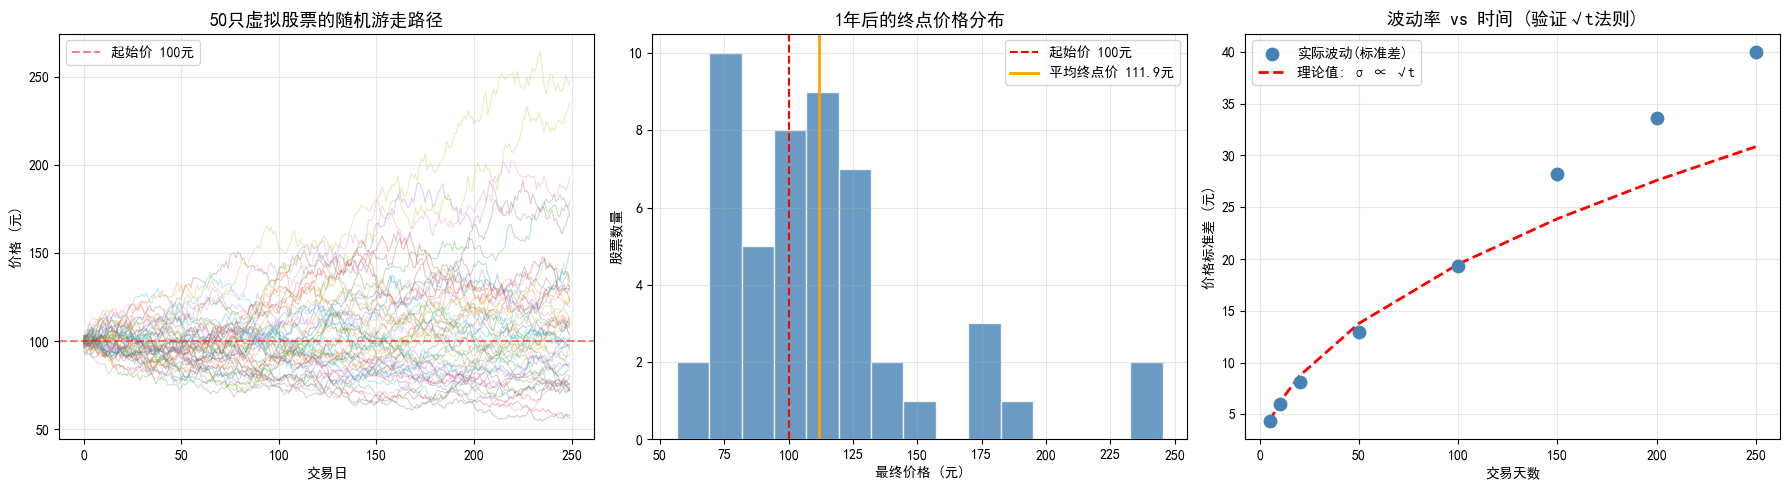

实验结论：
  50只股票起始价均为 100元
  1年后最高价: 245.32元
  1年后最低价: 56.49元
  1年后平均价: 111.92元
  价格标准差:  39.98元
------------------------------------------------------------
  → 每条路径完全不可预测（左图）
  → 但大量路径的终点价格呈正态分布（中图）
  → 波动幅度与时间平方根成正比（右图）——Regnault 1860年代的发现！


In [3]:
# ========== 实验一：布朗运动 / 随机游走 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(2026)        # 固定随机种子

n_stocks = 50               # 模拟 50 只「虚拟股票」
n_days = 250                # 每只走 250 个交易日（约一年）
start_price = 100           # 起始价都是 100 元
daily_volatility = 0.02     # 日波动强度（标准差约2%）

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1行3列，三个子图

# --- 左图：画出 50 条价格路径 ---
all_paths = []              # 用来存每只股票的路径
for _ in range(n_stocks):   # 循环 50 次，每只股一条路径
    daily_returns = np.random.normal(0, daily_volatility, n_days)  # 每天随机收益
    price_path = start_price * np.cumprod(1 + daily_returns)       # 价格连乘
    all_paths.append(price_path)          # 存入列表
    axes[0].plot(price_path, alpha=0.3, linewidth=0.8)  # 画在左图，半透明

axes[0].axhline(y=start_price, color='red', linestyle='--', alpha=0.5, label='起始价 100元')  # 参考线
axes[0].set_title('50只虚拟股票的随机游走路径', fontsize=13)  # 设置上图标题
axes[0].set_xlabel('交易日')  # 执行本行代码
axes[0].set_ylabel('价格 (元)')  # 设置上图纵轴
axes[0].legend()  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

# --- 中图：一年后的终点价格分布（直方图）---
final_prices = [path[-1] for path in all_paths]   # 取每条路径最后一天的价格
axes[1].hist(final_prices, bins=15, color='steelblue', edgecolor='white', alpha=0.8)  # 画直方图
axes[1].axvline(x=start_price, color='red', linestyle='--', label=f'起始价 {start_price}元')  # 中图画垂直参考线
axes[1].axvline(x=np.mean(final_prices), color='orange', linestyle='-', linewidth=2,  # 中图画垂直参考线
                label=f'平均终点价 {np.mean(final_prices):.1f}元')  # 图例文字
axes[1].set_title('1年后的终点价格分布', fontsize=13)  # 设置下图标题
axes[1].set_xlabel('最终价格 (元)')  # 设置下图横轴（日期）
axes[1].set_ylabel('股票数量')  # 设置下图纵轴
axes[1].legend()                                    # 显示下图图例
axes[1].grid(True, alpha=0.3)  # 下图显示网格

# --- 右图：验证「波动 ∝ 时间的平方根」---
time_points = [5, 10, 20, 50, 100, 150, 200, 250]  # 选取若干观察日
std_at_time = []                                    # 存放每个时点的价格标准差
for t in time_points:  # 代码块开始
    prices_at_t = [path[t-1] for path in all_paths]  # 所有股票在第 t 天的价格
    std_at_time.append(np.std(prices_at_t))         # 算标准差

sqrt_time = np.sqrt(time_points)                    # 时间开平方
scale = std_at_time[0] / sqrt_time[0]               # 缩放系数，让理论线对齐第一个点

axes[2].scatter(time_points, std_at_time, s=80, color='steelblue', zorder=5, label='实际波动(标准差)')  # 右图：散点
axes[2].plot(time_points, scale * sqrt_time, 'r--', linewidth=2, label='理论值: σ ∝ √t')  # 右图：理论曲线
axes[2].set_title('波动率 vs 时间 (验证√t法则)', fontsize=13)  # 设置右图标题
axes[2].set_xlabel('交易天数')  # 执行本行代码
axes[2].set_ylabel('价格标准差 (元)')  # 执行本行代码
axes[2].legend()  # 执行本行代码
axes[2].grid(True, alpha=0.3)  # 透明度

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

# ========== 打印文字结论 ==========
print("=" * 60)  # 打印输出
print("实验结论：")  # 打印输出
print(f"  50只股票起始价均为 {start_price}元")  # 打印价格统计
print(f"  1年后最高价: {max(final_prices):.2f}元")  # 打印价格统计
print(f"  1年后最低价: {min(final_prices):.2f}元")  # 打印价格统计
print(f"  1年后平均价: {np.mean(final_prices):.2f}元")  # 格式化打印
print(f"  价格标准差:  {np.std(final_prices):.2f}元")  # 格式化打印
print("-" * 60)  # 打印输出
print("  → 每条路径完全不可预测（左图）")  # 打印分隔线或结论
print("  → 但大量路径的终点价格呈正态分布（中图）")  # 打印分隔线或结论
print("  → 波动幅度与时间平方根成正比（右图）——Regnault 1860年代的发现！")  # 打印分隔线或结论
print("=" * 60)  # 打印输出


**这个实验告诉我们什么？**

这正是巴舍利耶在1900年揭示的核心洞察：
- **单只股票的走势无法预测**——每条路径都像醉汉走路，随机且不重复
- **但大量股票的统计规律是确定的**——终点价格服从正态分布，波动与√t成正比
- 量化金融的核心逻辑就藏在这里：**不预测单一结果，而是利用统计规律**

---

#### 实验二：模拟索普的"概率优势"——微小的胜率偏移如何变成长期利润？

索普证明了：在21点游戏中，只要通过算牌获得**微小的概率优势（约 1%~2%）**，配合**凯利公式**管理每次下注金额，就能在长期内稳定盈利。

我们来模拟三种玩家，各进行 **1000 轮下注**：
- 🔴 **玩家A**（无优势）：每局胜率 50%，纯靠运气
- 🟢 **玩家B**（索普策略）：胜率 52%（仅多2%的优势），使用凯利公式管理仓位
- 🟡 **玩家C**（有优势但赌性重）：胜率 52%，但每次固定押 25% 的本金

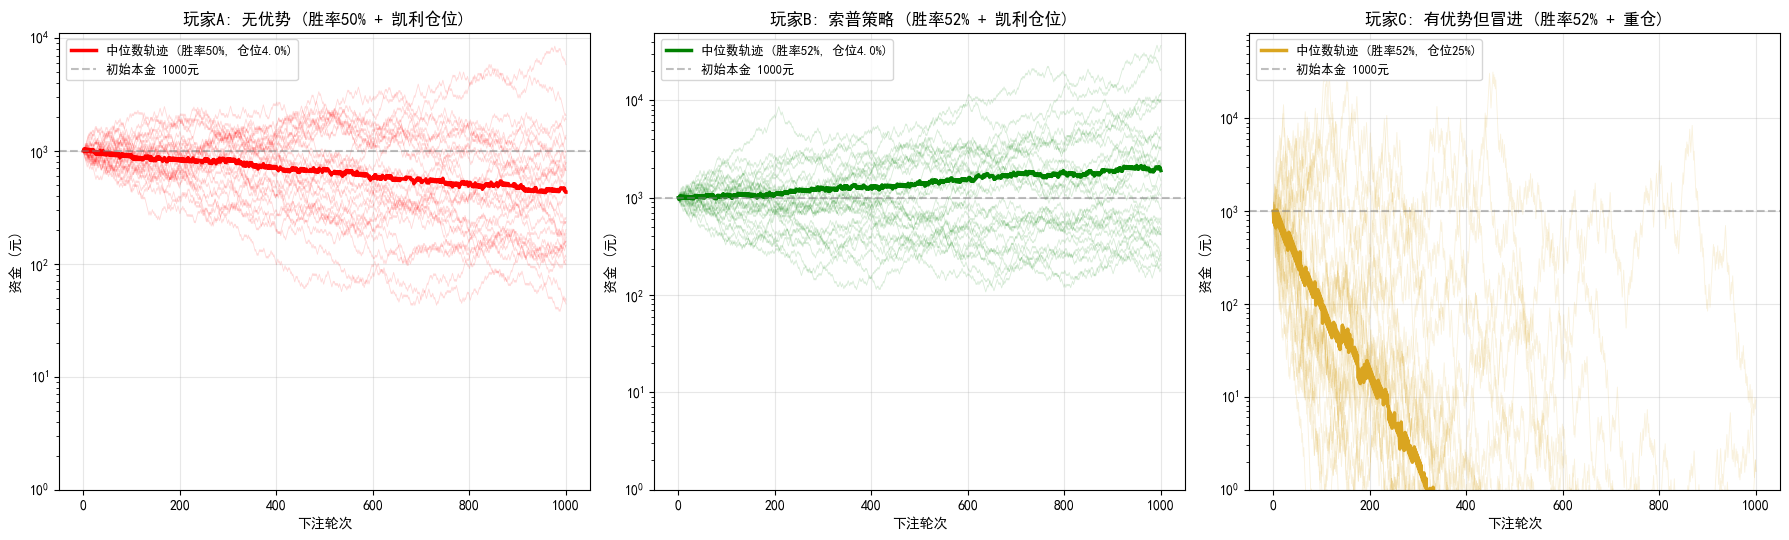

凯利公式计算: 最优下注比例 f* = 4.00% (胜率52%, 赔率1:1)

  【玩家A (无优势)】
    中位数终点资金: 432元
    盈利概率: 23.5%
    最好情况: 43,026元 | 最差情况: 13.27元

  【玩家B (索普策略)】
    中位数终点资金: 1,897元
    盈利概率: 70.5%
    最好情况: 50,495元 | 最差情况: 90.58元

  【玩家C (有优势但冒进)】
    中位数终点资金: 0元
    盈利概率: 0.0%
    最好情况: 916元 | 最差情况: 0.01元

  → 没有概率优势，凯利公式也救不了你（玩家A）
  → 仅仅2%的胜率优势 + 科学仓位管理 = 长期稳定复利（玩家B）
  → 有优势但仓位过重，反而可能亏光（玩家C）
  → 这就是索普的核心发现：概率优势 × 仓位管理 = 量化盈利的底层公式


In [4]:
# ========== 实验二：索普——概率优势 + 凯利仓位 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(2026)  # 固定随机种子，结果可复现

n_rounds = 1000             # 每位玩家模拟下注 1000 轮
n_simulations = 200         # 每种策略重复 200 次（看分布）
initial_capital = 1000      # 初始本金 1000 元

win_prob_no_edge = 0.50     # 玩家A：无优势，胜率 50%
win_prob_edge = 0.52        # 玩家B/C：有 2% 概率优势
payout_ratio = 1.0          # 赔率 1:1（赢一倍赌注，输一倍赌注）

# 凯利公式: f* = (bp - q) / b  → 最优下注占本金比例
kelly_fraction = (payout_ratio * win_prob_edge - (1 - win_prob_edge)) / payout_ratio  # 凯利公式最优下注比例
aggressive_fraction = 0.25  # 玩家C：有优势但每次下注 25%（太激进）


def simulate_player(win_prob, bet_fraction, n_sims=n_simulations):  # 定义模拟下注函数
    """模拟多人在 n_rounds 轮里的资金曲线。"""  # 字典字段
    all_curves = []              # 存放每次实验的资金曲线
    for _ in range(n_sims):              # 外层：重复很多次实验
        capital = initial_capital        # 本轮起始资金
        curve = [capital]              # 记录每轮后的资金
        for _ in range(n_rounds):      # 内层：一轮轮下注
            bet = capital * bet_fraction   # 本轮下注额 = 本金 × 比例
            if np.random.random() < win_prob:  # 随机数小于胜率 → 赢
                capital += bet * payout_ratio  # 赢：拿回赌注并赚一倍
            else:                              # 否则 → 输
                capital -= bet                 # 输：输掉本轮赌注
            capital = max(capital, 0.01)       # 防止资金变成负数
            curve.append(capital)  # 执行本行代码
        all_curves.append(curve)  # 执行本行代码
    return np.array(all_curves)        # 转成二维数组：行=实验，列=轮次


curves_A = simulate_player(win_prob_no_edge, kelly_fraction)       # 无优势 + 凯利
curves_B = simulate_player(win_prob_edge, kelly_fraction)          # 有优势 + 凯利
curves_C = simulate_player(win_prob_edge, aggressive_fraction)     # 有优势 + 重仓

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))  # 三个玩家各一张子图

configs = [  # 三个子图的配置
    (curves_A, '玩家A: 无优势 (胜率50% + 凯利仓位)', 'red', f'胜率50%, 仓位{kelly_fraction*100:.1f}%'),  # 执行本行代码
    (curves_B, '玩家B: 索普策略 (胜率52% + 凯利仓位)', 'green', f'胜率52%, 仓位{kelly_fraction*100:.1f}%'),  # 执行本行代码
    (curves_C, '玩家C: 有优势但冒进 (胜率52% + 重仓)', 'goldenrod', f'胜率52%, 仓位25%'),  # 执行本行代码
]                                              # 数组拼接结束

for ax, (curves, title, color, label) in zip(axes, configs):  # 为每个玩家画子图
    for i in range(min(30, n_simulations)):   # 只画前30条细线，避免太乱
        ax.plot(curves[i], alpha=0.15, linewidth=0.6, color=color)  # 在子图上画折线
    median_curve = np.median(curves, axis=0)  # 200次实验的中位数轨迹
    ax.plot(median_curve, color=color, linewidth=2.5, label=f'中位数轨迹 ({label})')  # 在子图上画折线
    ax.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label=f'初始本金 {initial_capital}元')  # 画水平参考线
    ax.set_title(title, fontsize=12, fontweight='bold')  # 设置子图标题
    ax.set_xlabel('下注轮次')  # 设置子图横轴
    ax.set_ylabel('资金 (元)')  # 设置子图纵轴
    ax.legend(fontsize=9, loc='upper left')  # 显示图例
    ax.grid(True, alpha=0.3)  # 显示网格
    ax.set_yscale('log')      # 纵轴用对数刻度，差距大时更好看
    ax.set_ylim(1, None)  # 设置纵轴范围

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print("=" * 70)  # 打印输出
print(f"凯利公式计算: 最优下注比例 f* = {kelly_fraction*100:.2f}% (胜率52%, 赔率1:1)")  # 打印凯利公式结果
print("=" * 70)  # 打印输出

for name, curves, color in [("玩家A (无优势)", curves_A, "red"),  # 打印各玩家统计
                              ("玩家B (索普策略)", curves_B, "green"),  # 执行本行代码
                              ("玩家C (有优势但冒进)", curves_C, "goldenrod")]:  # 代码块开始
    finals = curves[:, -1]                    # 每个实验最后一轮的资金
    win_rate = np.mean(finals > initial_capital) * 100  # 最终赚钱的比例
    median_final = np.median(finals)  # 赋值：median_final
    print(f"\n  【{name}】")  # 格式化打印
    print(f"    中位数终点资金: {median_final:,.0f}元")  # 格式化打印
    print(f"    盈利概率: {win_rate:.1f}%")  # 格式化打印
    print(f"    最好情况: {np.max(finals):,.0f}元 | 最差情况: {np.min(finals):,.2f}元")  # 格式化打印

print("\n" + "=" * 70)  # 打印输出
print("  → 没有概率优势，凯利公式也救不了你（玩家A）")  # 打印分隔线或结论
print("  → 仅仅2%的胜率优势 + 科学仓位管理 = 长期稳定复利（玩家B）")  # 打印分隔线或结论
print("  → 有优势但仓位过重，反而可能亏光（玩家C）")  # 打印分隔线或结论
print("  → 这就是索普的核心发现：概率优势 × 仓位管理 = 量化盈利的底层公式")  # 打印分隔线或结论
print("=" * 70)  # 打印输出


**这个实验告诉我们什么？**

这正是索普在1961年用真金白银验证过的道理：

| | 概率优势 | 仓位管理 | 长期结果 |
|---|---------|---------|---------|
| 玩家A | ❌ 无 | ✅ 凯利公式 | 随机波动，不赚不亏 |
| 玩家B | ✅ 2%优势 | ✅ 凯利公式 | **稳定盈利，复利增长** |
| 玩家C | ✅ 2%优势 | ❌ 过度下注 | 大起大落，可能亏光 |

**量化金融的底层逻辑：**
1. **找到概率优势**（策略研究的目标）——没有优势，一切仓位管理都无效
2. **科学管理仓位**（风险控制的目标）——有优势但不控制风险，照样亏钱
3. **长期重复执行**（纪律与系统的目标）——让大数定律为你工作

> **概率优势 × 仓位管理 × 长期纪律 = 量化盈利的完整公式**
>
> 这是索普在赌场验证的真理，也是所有量化策略的底层逻辑。

> ## ***量化金融的核心：***
> ## ***不是预测未来，***
> ## ***而是用数据理解市场。***

---

### 1.7 ⭐ 本章爽点：你拿到真实股票数据了

前面是理论和模拟实验。

这一节只做一件事——让你产生 **「卧槽，我居然真的拉到苹果股价了」** 的感觉。

（第二章会系统讲 OHLCV 和收益率；这里先体验 **成就感**。）

🎉 恭喜！你已经拿到真实股票数据
   共 125 个交易日
   最新收盘价: $290.86


,Close,High,Low,Open,Volume
Date,,,,,
2026-06-05,307.339996,315.170013,307.149994,312.859985,65310500
2026-06-08,301.540009,317.399994,301.170013,308.739990,77949100
2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
2026-06-10,291.579987,294.750000,287.380005,290.739990,52608100
2026-06-11,290.859985,293.950012,289.600006,293.720001,10217340


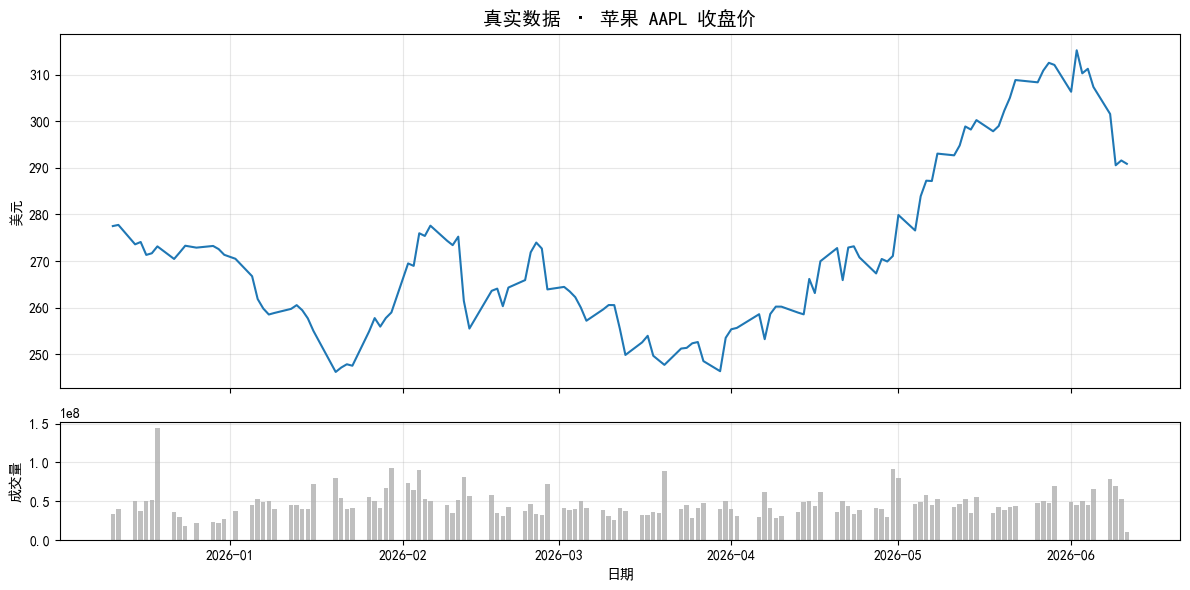

In [5]:
# ========== 第一章爽点：下载真实股票数据 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')   # 隐藏不影响学习的警告信息

import matplotlib.pyplot as plt     # 画图
import yfinance as yf               # 从雅虎财经免费下载行情

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

# 一行下载苹果 AAPL 最近 6 个月的日线（需要联网）
aapl = yf.download('AAPL', period='6mo', progress=False, multi_level_index=False)  # 下载股票日线行情

print('🎉 恭喜！你已经拿到真实股票数据')  # 打印输出
print(f'   共 {len(aapl)} 个交易日')                              # 行数 = 交易日个数
print(f'   最新收盘价: ${aapl["Close"].iloc[-1]:.2f}')            # iloc[-1] = 最后一行
display(aapl.tail(5))   # 在 Notebook 里美观地显示最后 5 行表格

# ========== 上图收盘价、下图成交量 ==========
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,       # 2行子图，横轴对齐
                         gridspec_kw={'height_ratios': [3, 1]})    # 上图占 3 份高度
axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.5)  # 折线：收盘价
axes[0].set_title('真实数据 · 苹果 AAPL 收盘价', fontsize=14)  # 设置上图标题
axes[0].set_ylabel('美元')  # 设置上图纵轴
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].bar(aapl.index, aapl['Volume'], width=0.8, color='gray', alpha=0.5)  # 柱状：成交量
axes[1].set_ylabel('成交量')  # 设置下图纵轴
axes[1].set_xlabel('日期')  # 设置下图横轴（日期）
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片


---

## 🎯 挑战任务（第一章通关）

换一只股票，亲手跑出同样的「爽感」：

1. 把上面代码里的 `'AAPL'` 改成 **`'TSLA'`**（特斯拉）或 **`'NVDA'`**（英伟达）
2. 重新运行，画出 **价格 + 成交量** 图
3. 在纸上或评论区回答：**最新收盘价是多少？近 6 个月整体是涨还是跌？**

## 本章总结

- 量化 = 用 **规则 + 数据** 做决策，不是凭感觉猜涨跌
- 核心流程：**提假设 → 找数据 → 回测验证 → 形成策略**
- 你已经完成 **Lv.1 量化探索者** 的入门体验

**下一章**：系统学习股票数据长什么样、什么是收益率——从「爽一下」到「会分析」。

> ⭐ 觉得有用？可以先 **Star 收藏** 本仓库，第二章马上接上。